In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# from libsvmdata import fetch_dataset
from sklearn.datasets import make_moons, make_friedman1, make_gaussian_quantiles, make_regression
import time

In [2]:
# Setup

SEED = 42 # for reproducibility
np.random.seed(SEED)
T = 500 # number of trials

N, d = 1000, 10
X = np.random.rand(N, d)

# only use the SVD
# X, _, _ = np.linalg.svd(X, full_matrices=False)

# y = np.random.rand(X.shape[0])
# X,y = make_moons(N, random_state=SEED)
# d = 2

# X,y = make_friedman1(N,d,random_state=SEED)

X,y = make_gaussian_quantiles(n_samples=N, n_features=d, n_classes=2, random_state=SEED)


In [30]:
def chaining_method(X,y,N,d, title, T=100):
    w_star, _,  _, _ = np.linalg.lstsq(X, y, rcond=None)
    err_star = np.linalg.norm(X @ w_star - y, ord=2)**2


    max_removed = int(.6 * N) # only remove up to .6 of the data
    # chaining
    # use at least d points, label budget <b> -> index <b> - d

    chaining_exps = [np.full(N, np.nan) for _ in range(T)] # will not use all of this
    for t in range(T):
        start_time = time.time()
        AtA = np.zeros((d, d), dtype=float)
        X_minus = X.copy()
        y_minus = y.copy()
        for k in range(1, max_removed+1):
            # the inverse is negligible since matrix is of size d x d
            leverages = np.einsum('ij,jk,ik->i', X_minus, np.linalg.inv(np.eye(d) -  AtA), X_minus)
            leverages[leverages == 0] = 1 # this will ingnore 0 rows, will not sample rows that is already picked and has been zeroed out
            probs = (1 - leverages)**2 / leverages
            probs /= np.sum(probs)
            
            i = np.random.choice(np.arange(N), p=probs)
            X_minus[i] = 0
            wA_minus = np.linalg.lstsq(X_minus, y_minus, rcond=None)[0]
            label_budget = N - k - 1
            chaining_exps[t][label_budget] = np.linalg.norm(X @ wA_minus - y, ord=2)**2 / err_star
        end_time = time.time()
        print(f"Trial {t+1}/{T} completed in {end_time - start_time:.2f} seconds")

    print(err_star)
    chaining_exps = np.array(chaining_exps)
    budgets = np.arange(N - max_removed, N)


    chaining_data = []
    poly_sampling_data = []
    leverage_score_data = []
    for t in range(T-1):
        for b in budgets:
            # print(t, b-1)
            chaining_data.append({
                "Budget": b,
                "Error": chaining_exps[t][b-1]-1,
                "Trial": t
            })

    chaining_df = pd.DataFrame(chaining_data)

    # Plot
    sns.set(style="whitegrid", context="talk")
    plt.figure()
    sns.lineplot(
        data=chaining_df,
        x="Budget",
        y="Error",
        errorbar="sd",   # shaded ±1 std
        estimator="mean",
        label="(A)"
    )



    plt.axhline(y=d/N, linestyle='--', label="d/N")
    # plt.title(title)
    plt.xlim(N - max_removed, N)
    plt.yscale("log")

    plt.xlabel("Label Budget")
    plt.ylabel("Approximation Error - 1")
    plt.legend()
    plt.tight_layout()
    plt.show()

Trial 1/100 completed in 0.31 seconds
Trial 2/100 completed in 0.31 seconds
Trial 3/100 completed in 0.31 seconds
Trial 4/100 completed in 0.35 seconds
Trial 5/100 completed in 0.30 seconds
Trial 6/100 completed in 0.17 seconds
Trial 7/100 completed in 0.19 seconds
Trial 8/100 completed in 0.18 seconds
Trial 9/100 completed in 0.15 seconds
Trial 10/100 completed in 0.15 seconds
Trial 11/100 completed in 0.16 seconds
Trial 12/100 completed in 0.15 seconds
Trial 13/100 completed in 0.16 seconds
Trial 14/100 completed in 0.15 seconds
Trial 15/100 completed in 0.15 seconds
Trial 16/100 completed in 0.15 seconds
Trial 17/100 completed in 0.15 seconds
Trial 18/100 completed in 0.15 seconds
Trial 19/100 completed in 0.16 seconds
Trial 20/100 completed in 0.15 seconds
Trial 21/100 completed in 0.15 seconds
Trial 22/100 completed in 0.15 seconds
Trial 23/100 completed in 0.15 seconds
Trial 24/100 completed in 0.17 seconds
Trial 25/100 completed in 0.16 seconds
Trial 26/100 completed in 0.19 sec

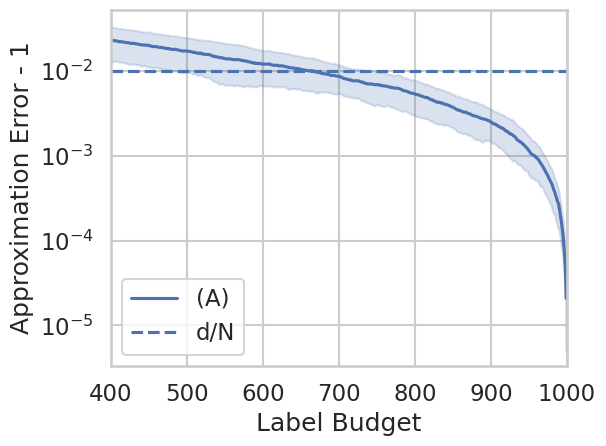

In [4]:
chaining_method(X,y,N,d, "Gaussian Quantiles 2 Classes")

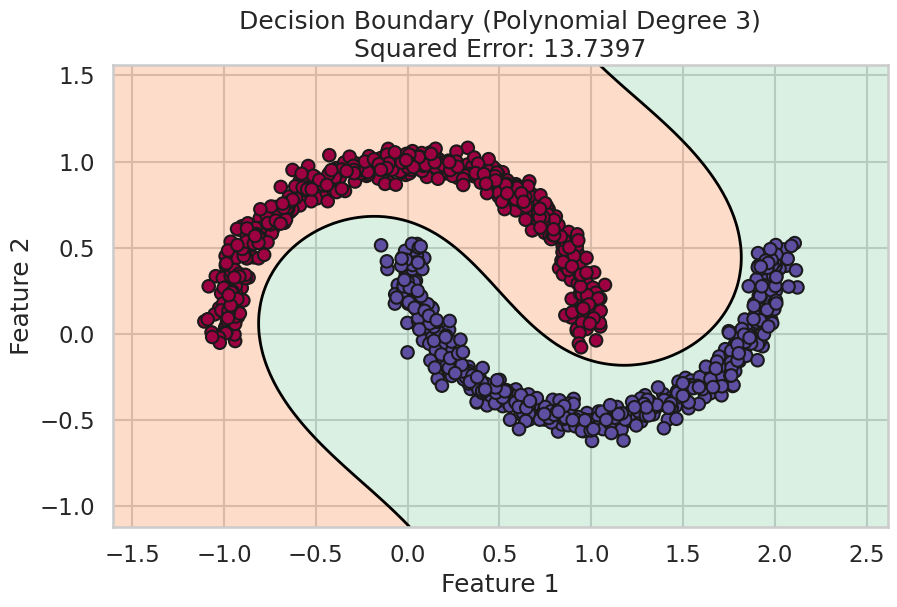

In [41]:
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(N, noise=0.05, random_state=SEED)
poly = PolynomialFeatures(degree=3)
X = poly.fit_transform(X)
d = X.shape[1]
w_star, _,  _, _ = np.linalg.lstsq(X, y, rcond=None)
err_star = np.linalg.norm(X @ w_star - y, ord=2)**2

# Plot the classification boundary
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a mesh grid to cover the feature space
h = .02  # step size in the mesh
x_min, x_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
y_min, y_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 2. Prepare the grid points for prediction
# We flatten the grid and pass it through the same polynomial transformer
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid_points)

# 3. Calculate predictions (Z = X_poly @ w_star)
Z = grid_poly @ w_star
Z = Z.reshape(xx.shape)

# 4. Plotting
plt.figure(figsize=(10, 6))

# Plot the decision boundary (where the prediction is 0.5)
# We use contour to draw the line and contourf for the background color
plt.contourf(xx, yy, Z > 0.5, alpha=0.3, cmap='Spectral')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

# Plot the original data points
# Note: Using X[:, 1] and X[:, 2] because X[:, 0] is the bias (1s)
plt.scatter(X[:, 1], X[:, 2], c=y, edgecolors='k', cmap='Spectral')

plt.title(f"Decision Boundary (Polynomial Degree {3})\nSquared Error: {err_star:.4f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Trial 1/100 completed in 0.31 seconds
Trial 2/100 completed in 0.30 seconds
Trial 3/100 completed in 0.31 seconds
Trial 4/100 completed in 0.30 seconds
Trial 5/100 completed in 0.26 seconds
Trial 6/100 completed in 0.15 seconds
Trial 7/100 completed in 0.24 seconds
Trial 8/100 completed in 0.30 seconds
Trial 9/100 completed in 0.30 seconds
Trial 10/100 completed in 0.31 seconds
Trial 11/100 completed in 0.30 seconds
Trial 12/100 completed in 0.30 seconds
Trial 13/100 completed in 0.30 seconds
Trial 14/100 completed in 0.33 seconds
Trial 15/100 completed in 0.33 seconds
Trial 16/100 completed in 0.33 seconds
Trial 17/100 completed in 0.32 seconds
Trial 18/100 completed in 0.31 seconds
Trial 19/100 completed in 0.32 seconds
Trial 20/100 completed in 0.32 seconds
Trial 21/100 completed in 0.32 seconds
Trial 22/100 completed in 0.16 seconds
Trial 23/100 completed in 0.20 seconds
Trial 24/100 completed in 0.17 seconds
Trial 25/100 completed in 0.15 seconds
Trial 26/100 completed in 0.15 sec

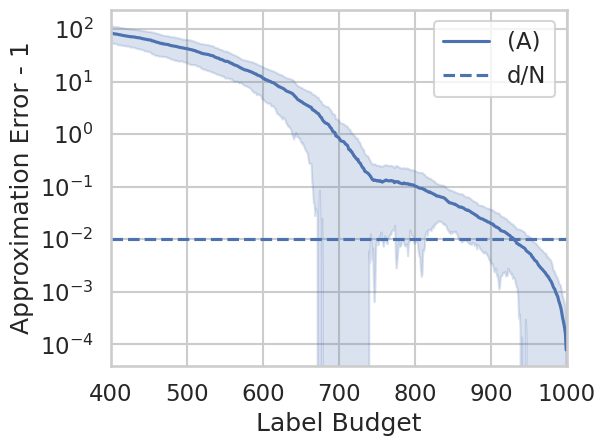

In [35]:
chaining_method(X,y,N,d,"Perfectly Separated Moons",100)

Trial 1/100 completed in 0.07 seconds
Trial 2/100 completed in 0.05 seconds
Trial 3/100 completed in 0.05 seconds
Trial 4/100 completed in 0.05 seconds
Trial 5/100 completed in 0.05 seconds
Trial 6/100 completed in 0.05 seconds
Trial 7/100 completed in 0.05 seconds
Trial 8/100 completed in 0.05 seconds
Trial 9/100 completed in 0.05 seconds
Trial 10/100 completed in 0.05 seconds
Trial 11/100 completed in 0.05 seconds
Trial 12/100 completed in 0.05 seconds
Trial 13/100 completed in 0.05 seconds
Trial 14/100 completed in 0.05 seconds
Trial 15/100 completed in 0.05 seconds
Trial 16/100 completed in 0.05 seconds
Trial 17/100 completed in 0.05 seconds
Trial 18/100 completed in 0.05 seconds
Trial 19/100 completed in 0.05 seconds
Trial 20/100 completed in 0.05 seconds
Trial 21/100 completed in 0.05 seconds
Trial 22/100 completed in 0.05 seconds
Trial 23/100 completed in 0.05 seconds
Trial 24/100 completed in 0.05 seconds
Trial 25/100 completed in 0.05 seconds
Trial 26/100 completed in 0.06 sec

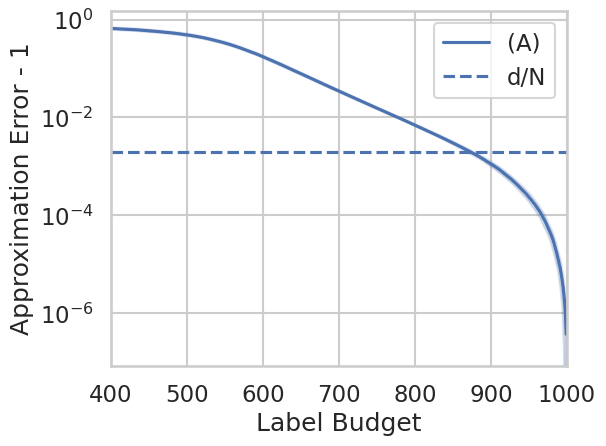

In [32]:
X, y = make_moons(N, noise=0.05, random_state=SEED)
d = X.shape[1]
chaining_method(X,y,N,d,"Moons",100)

(1000, 20)
Trial 1/100 completed in 0.52 seconds
Trial 2/100 completed in 0.56 seconds
Trial 3/100 completed in 0.59 seconds
Trial 4/100 completed in 0.63 seconds
Trial 5/100 completed in 0.59 seconds
Trial 6/100 completed in 0.53 seconds
Trial 7/100 completed in 0.51 seconds
Trial 8/100 completed in 0.50 seconds
Trial 9/100 completed in 0.67 seconds
Trial 10/100 completed in 0.56 seconds
Trial 11/100 completed in 0.75 seconds
Trial 12/100 completed in 0.91 seconds
Trial 13/100 completed in 0.91 seconds
Trial 14/100 completed in 0.90 seconds
Trial 15/100 completed in 0.91 seconds
Trial 16/100 completed in 0.90 seconds
Trial 17/100 completed in 0.90 seconds
Trial 18/100 completed in 0.90 seconds
Trial 19/100 completed in 0.90 seconds
Trial 20/100 completed in 0.91 seconds
Trial 21/100 completed in 0.90 seconds
Trial 22/100 completed in 0.91 seconds
Trial 23/100 completed in 0.90 seconds
Trial 24/100 completed in 0.78 seconds
Trial 25/100 completed in 0.90 seconds
Trial 26/100 completed 

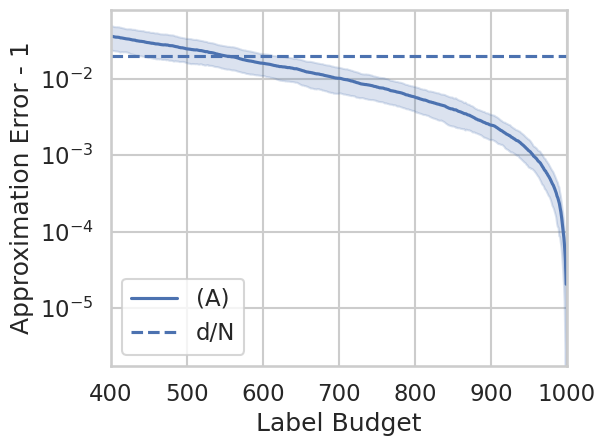

In [43]:
d = 20
X,y = make_regression(N, n_features=d, n_informative=d//2, noise=0.002, random_state=SEED)
# plt.scatter(X[:,0],X[:,1])
print(X.shape)
chaining_method(X,y,N,d,"None")